# Task 2. Face Recognition (Cross-Entropy vs ArcFace) — Kaggle Notebooks

Задание (4 балла): обучить нейросеть для 3 части пайплайна (распознавание лиц) на CE loss (backbone —
любая архитектура, предобученная на ImageNet, но НЕ на распознавании лиц), реализовать ArcFace и обучить
такую же модель на нём, сравнить.

## Как экономить бесплатную GPU-квоту Kaggle (30 ч/неделю)

- **Фаза A (CPU)** — скачивание raw-изображений CelebA, identity-aware отбор, кроп по bbox. Чистый
  `pandas`/`cv2`, GPU не нужен. В `Settings → Accelerator` выберите **None**.
- **Фаза B (GPU)** — загрузка весов Hourglass из Task 1, выравнивание лиц (инференс) и обучение
  CE/ArcFace моделей. В `Settings → Accelerator` выберите **GPU T4 x2** (или P100).

**Веса Hourglass из Task 1.


In [2]:
import os

WORKING_DIR = '/kaggle/working'
TASK1_INPUT_DIR = '/kaggle/input/notebooks/iuliiaburmistrova/notebook0e9be24a8a'
print('Рабочая папка Kaggle:', WORKING_DIR)
print('Ожидаемый путь к выходу Task 1:', TASK1_INPUT_DIR)


Рабочая папка Kaggle: /kaggle/working
Ожидаемый путь к выходу Task 1: /kaggle/input/notebooks/iuliiaburmistrova/notebook0e9be24a8a


In [ ]:
import os
import math
import shutil
import random

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models, datasets

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


---
# Фаза A (CPU) — скачивание и отбор данных для распознавания

Этот раздел не требует GPU — Убедитесь, что среда выполнения — CPU.


## 2.1 Identity-aware отбор + кроп

Отбор данных для Task 2 работает иначе, чем для Task 1: Для распознавания лиц (в отличие от Task 1) нужно много
фото на каждую личность, иначе модели не на чем учиться отличать одного человека от другого. Поэтому
здесь используется отдельный, **identity-aware** отбор — с гарантированным минимумом фото на личность.


In [4]:
!pip install -q kagglehub gdown

import kagglehub
import gdown

KAGGLE_DATASET = 'kevinpatel04/celeba-original-wild-images'
kaggle_path = kagglehub.dataset_download(KAGGLE_DATASET)
print('Датасет скачан в:', kaggle_path)

CELEBA_ROOT = 'data/celeba'
os.makedirs(CELEBA_ROOT, exist_ok=True)

BBOX_FILE = os.path.join(kaggle_path, 'list_bbox_celeba.csv')
ATTR_FILE = os.path.join(kaggle_path, 'list_attr_celeba.csv')

LANDMARKS_FILE = os.path.join(TASK1_INPUT_DIR, 'data/celeba/list_landmarks_celeba.txt')
IDENTITY_FILE = os.path.join(TASK1_INPUT_DIR, 'data/celeba/identity_CelebA.txt')
assert os.path.exists(LANDMARKS_FILE) and os.path.exists(IDENTITY_FILE), \
    'Файлы не найдены в выводе Task 1 — проверьте TASK1_INPUT_DIR'
print('landmarks и identity подхвачены из Task 1, повторное скачивание не нужно')


def build_image_index(kaggle_path, n_parts=21):
    index = {}
    for i in range(1, n_parts + 1):
        part_dir = os.path.join(kaggle_path, f'Part {i}', f'Part {i}')
        if not os.path.isdir(part_dir):
            continue
        for fname in os.listdir(part_dir):
            index[fname] = os.path.join(part_dir, fname)
    return index

IMAGE_INDEX = build_image_index(kaggle_path)
print('Найдено изображений в индексе:', len(IMAGE_INDEX))


def load_celeba_annotations():
    bbox = pd.read_csv(BBOX_FILE)
    attr = pd.read_csv(ATTR_FILE)
    landmarks = pd.read_csv(LANDMARKS_FILE, sep=r'\s+', skiprows=1)
    landmarks = landmarks.reset_index().rename(columns={'index': 'image_id'})
    identity = pd.read_csv(IDENTITY_FILE, sep=r'\s+', header=None, names=['image_id', 'identity'])
    return bbox.merge(landmarks, on='image_id').merge(attr, on='image_id').merge(identity, on='image_id')


df = load_celeba_annotations()


BBOX_MARGIN = 0.35


def select_subset_for_recognition(df, min_photos_per_identity=15, max_per_identity=30,
                                   max_identities=400, seed=SEED):
    """В отличие от отбора для Task 1, тут отбор идёт по личностям: берём только тех, у кого
    достаточно фото, чтобы модель могла выучить внутриклассовое сходство."""
    filtered = df.copy()
    if 'Blurry' in filtered.columns:
        filtered = filtered[filtered['Blurry'] != 1]

    counts = filtered['identity'].value_counts()
    eligible = counts[counts >= min_photos_per_identity].index.tolist()
    print(f'Личностей с >= {min_photos_per_identity} фото в общем пуле: {len(eligible)}')

    rng = np.random.RandomState(seed)
    if len(eligible) > max_identities:
        eligible = list(rng.choice(eligible, size=max_identities, replace=False))

    subset = filtered[filtered['identity'].isin(eligible)]
    subset = (subset.groupby('identity', group_keys=False)
              .apply(lambda g: g.sample(min(len(g), max_per_identity), random_state=seed)))
    return subset.reset_index(drop=True)


def crop_and_save(df, image_index, out_dir, margin=BBOX_MARGIN):
    """Чистый cv2/numpy — GPU не используется."""
    os.makedirs(os.path.join(out_dir, 'images'), exist_ok=True)
    records, skipped = [], 0
    for _, row in df.iterrows():
        img_path = image_index.get(row['image_id'])
        if img_path is None:
            skipped += 1
            continue
        img = cv2.imread(img_path)
        if img is None:
            skipped += 1
            continue
        h, w = img.shape[:2]
        x1, y1, bw, bh = row['x_1'], row['y_1'], row['width'], row['height']
        mx, my = bw * margin, bh * margin
        x1c, y1c = max(0, int(x1 - mx)), max(0, int(y1 - my))
        x2c, y2c = min(w, int(x1 + bw + mx)), min(h, int(y1 + bh + my))
        crop = img[y1c:y2c, x1c:x2c]
        if crop.size == 0:
            skipped += 1
            continue
        cv2.imwrite(os.path.join(out_dir, 'images', row['image_id']), crop)
        records.append({'image_id': row['image_id'], 'identity': row['identity']})
    if skipped:
        print(f'Пропущено {skipped} изображений')
    result = pd.DataFrame(records)
    result.to_csv(os.path.join(out_dir, 'selected_dataset.csv'), index=False)
    return result


recog_subset = select_subset_for_recognition(df)
print(f'Итого личностей: {recog_subset["identity"].nunique()}, фото: {len(recog_subset)}')

recog_prepared = crop_and_save(recog_subset, IMAGE_INDEX, out_dir='data/prepared_recog')
print(f'Кропнуто: {len(recog_prepared)}')

if kaggle_path and os.path.exists(kaggle_path):
    shutil.rmtree(kaggle_path, ignore_errors=True)
    print('Сырые изображения удалены')


Датасет скачан в: /kaggle/input/datasets/kevinpatel04/celeba-original-wild-images
landmarks и identity подхвачены из Task 1, повторное скачивание не нужно
Найдено изображений в индексе: 202599
Личностей с >= 15 фото в общем пуле: 7130
Итого личностей: 400, фото: 9658


/tmp/ipykernel_58/2376662698.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), max_per_identity), random_state=seed)))


Кропнуто: 9658


KeyboardInterrupt: 

### Фаза A завершена

Файлы уже в персистентной `/kaggle/working` — копировать никуда не нужно. Для надёжности перед сменой
ускорителя нажмите **Save Version → Quick Save**.

---
# Фаза B (GPU) — выравнивание и обучение распознавания

**В `Settings → Accelerator` выберите GPU T4 x2 (или P100) перед этой частью.** Смена ускорителя
перезапускает сессию — заново выполните ячейки импортов из самого начала, затем продолжайте отсюда.


In [5]:
# Проверяем, что данные Фазы A на месте
assert os.path.exists('data/prepared_recog/selected_dataset.csv'), \
    'Данные Фазы A не найдены — перезапустите Фазу A или проверьте Save Version'
print('data/prepared_recog на месте')

# Подхватываем веса Hourglass из Task 1 (добавлен через + Add Data -> Notebook Output Files)
os.makedirs('checkpoints_hourglass', exist_ok=True)
if not os.path.exists('checkpoints_hourglass/best.pth'):
    import shutil as _sh
    hg_source = os.path.join(TASK1_INPUT_DIR, 'checkpoints_hourglass', 'best.pth')
    assert os.path.exists(hg_source), (
        f'{hg_source} не найден — проверьте, что Task 1 добавлен через + Add Data '
        f'и что TASK1_INPUT_DIR указывает на правильный slug'
    )
    _sh.copy(hg_source, 'checkpoints_hourglass/best.pth')
    print('Веса Hourglass из Task 1 подгружены из', hg_source)


data/prepared_recog на месте
Веса Hourglass из Task 1 подгружены из /kaggle/input/notebooks/iuliiaburmistrova/notebook0e9be24a8a/checkpoints_hourglass/best.pth


In [6]:
# --- Архитектура Hourglass из Task 1 (нужна только для инференса — выравнивания лиц) ---

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)
        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)


class Hourglass(nn.Module):
    def __init__(self, depth, num_channels):
        super().__init__()
        self.up1 = ResidualBlock(num_channels, num_channels)
        self.pool = nn.MaxPool2d(2)
        self.low1 = ResidualBlock(num_channels, num_channels)
        self.low2 = Hourglass(depth - 1, num_channels) if depth > 1 else ResidualBlock(num_channels, num_channels)
        self.low3 = ResidualBlock(num_channels, num_channels)
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        up1 = self.up1(x)
        pool = self.pool(x)
        low1 = self.low1(pool)
        low2 = self.low2(low1)
        low3 = self.low3(low2)
        up2 = self.up2(low3)
        return up1 + up2


class StackedHourglass(nn.Module):
    def __init__(self, num_stacks=4, num_channels=256, num_landmarks=5, hg_depth=4):
        super().__init__()
        self.num_stacks = num_stacks
        self.pre = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            ResidualBlock(64, 128), nn.MaxPool2d(2), ResidualBlock(128, 128), ResidualBlock(128, num_channels),
        )
        self.hourglasses = nn.ModuleList([Hourglass(hg_depth, num_channels) for _ in range(num_stacks)])
        self.features = nn.ModuleList([
            nn.Sequential(ResidualBlock(num_channels, num_channels), nn.Conv2d(num_channels, num_channels, 1),
                          nn.BatchNorm2d(num_channels), nn.ReLU(inplace=True))
            for _ in range(num_stacks)
        ])
        self.heatmap_heads = nn.ModuleList([nn.Conv2d(num_channels, num_landmarks, 1) for _ in range(num_stacks)])
        self.merge_features = nn.ModuleList([nn.Conv2d(num_channels, num_channels, 1) for _ in range(num_stacks - 1)])
        self.merge_heatmaps = nn.ModuleList([nn.Conv2d(num_landmarks, num_channels, 1) for _ in range(num_stacks - 1)])

    def forward(self, x):
        x = self.pre(x)
        outputs = []
        for i in range(self.num_stacks):
            hg_out = self.hourglasses[i](x)
            feat = self.features[i](hg_out)
            heatmap = self.heatmap_heads[i](feat)
            outputs.append(heatmap)
            if i < self.num_stacks - 1:
                x = x + self.merge_features[i](feat) + self.merge_heatmaps[i](heatmap)
        return outputs


def heatmaps_to_landmarks(heatmaps):
    landmarks = []
    for hm in heatmaps:
        y, x = np.unravel_index(np.argmax(hm), hm.shape)
        landmarks.append((float(x), float(y)))
    return np.array(landmarks, dtype=np.float32)


@torch.no_grad()
def predict_landmarks(model, image_rgb, img_size=256, heatmap_size=64, device=DEVICE):
    model.eval()
    resized = cv2.resize(image_rgb, (img_size, img_size))
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    tensor = torch.from_numpy(resized).permute(2, 0, 1).float() / 255.0
    tensor = normalize(tensor).unsqueeze(0).to(device)
    heatmaps = model(tensor)[-1][0].cpu().numpy()
    return resized, heatmaps_to_landmarks(heatmaps) * (img_size / heatmap_size)


REFERENCE_LANDMARKS_112 = np.array([
    [38.2946, 51.6963], [73.5318, 51.5014], [56.0252, 71.7366],
    [41.5493, 92.3655], [70.7299, 92.2041],
], dtype=np.float32)


def align_face(image_rgb, landmarks, output_size=112):
    ref = REFERENCE_LANDMARKS_112.copy() * (output_size / 112.0)
    src = np.asarray(landmarks, dtype=np.float32)
    M, _ = cv2.estimateAffinePartial2D(src, ref, method=cv2.LMEDS)
    if M is None:
        return cv2.resize(image_rgb, (output_size, output_size))
    return cv2.warpAffine(image_rgb, M, (output_size, output_size), borderValue=(0, 0, 0))


hg_model = StackedHourglass(num_stacks=4, num_channels=256, num_landmarks=5, hg_depth=4)
hg_model.load_state_dict(torch.load('checkpoints_hourglass/best.pth', map_location=DEVICE))
hg_model = hg_model.to(DEVICE)
hg_model.eval()
print('Hourglass веса из Task 1 загружены')


Hourglass веса из Task 1 загружены


### Выравнивание (инференс через Hourglass — GPU ускоряет заметно) + раскладка по личностям

In [7]:
@torch.no_grad()
def build_aligned_dataset(model, csv_file, img_dir, output_dir,
                           img_size=256, heatmap_size=64, output_size=112, device=DEVICE):
    model.eval()
    os.makedirs(os.path.join(output_dir, 'images'), exist_ok=True)
    df_local = pd.read_csv(csv_file)
    records = []
    for _, row in df_local.iterrows():
        img = cv2.imread(os.path.join(img_dir, row['image_id']))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        resized, landmarks = predict_landmarks(model, img_rgb, img_size, heatmap_size, device)
        aligned = align_face(resized, landmarks, output_size)
        cv2.imwrite(os.path.join(output_dir, 'images', row['image_id']), cv2.cvtColor(aligned, cv2.COLOR_RGB2BGR))
        records.append({'image_id': row['image_id'], 'identity': row['identity']})
    result_df = pd.DataFrame(records)
    result_df.to_csv(os.path.join(output_dir, 'aligned_dataset.csv'), index=False)
    return result_df


def organize_by_identity(aligned_csv, aligned_img_dir, output_dir):
    df_local = pd.read_csv(aligned_csv)
    os.makedirs(output_dir, exist_ok=True)
    for _, row in df_local.iterrows():
        id_dir = os.path.join(output_dir, str(row['identity']))
        os.makedirs(id_dir, exist_ok=True)
        src = os.path.join(aligned_img_dir, row['image_id'])
        if os.path.exists(src):
            shutil.copy(src, os.path.join(id_dir, row['image_id']))


build_aligned_dataset(hg_model, 'data/prepared_recog/selected_dataset.csv',
                       'data/prepared_recog/images', 'data/aligned_recog')

shutil.rmtree('data/aligned_by_identity', ignore_errors=True)
organize_by_identity('data/aligned_recog/aligned_dataset.csv', 'data/aligned_recog/images',
                      'data/aligned_by_identity')
print('Готово: датасет для распознавания собран в data/aligned_by_identity')


Готово: датасет для распознавания собран в data/aligned_by_identity


## 2.2 Данные: `DataLoader` на базе `ImageFolder`

In [8]:
RECOG_DATA_DIR = 'data/aligned_by_identity'
EMBEDDING_SIZE = 512
IMG_SIZE = 112

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


def build_recognition_dataloaders(data_dir=RECOG_DATA_DIR, val_split=0.1, batch_size=128):
    full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
    n_val = int(len(full_dataset) * val_split)
    n_train = len(full_dataset) - n_val
    train_subset, val_subset = torch.utils.data.random_split(
        full_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
    val_subset.dataset.transform = val_transform

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, len(full_dataset.classes)


recog_train_loader, recog_val_loader, num_classes = build_recognition_dataloaders()
print('Number of identities (classes):', num_classes)


Number of identities (classes): 400


## 2.3 ArcFace head (`ArcMarginProduct`)

In [9]:
class ArcMarginProduct(nn.Module):
    """Additive Angular Margin (ArcFace). ArcFace — не лосс, а модификация логитов перед обычным CE:
    для целевого класса cos(theta) заменяется на cos(theta + m), для остальных классов остаётся
    обычный cos(theta). Обучение всё ещё идёт через CrossEntropyLoss.
    Статья: https://arxiv.org/abs/1801.07698"""

    def __init__(self, in_features, out_features, s=30.0, m=0.50, easy_margin=False):
        super().__init__()
        self.s, self.m = s, m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.easy_margin = easy_margin
        self.cos_m, self.sin_m = math.cos(m), math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, embeddings, labels):
        cosine = F.linear(F.normalize(embeddings), F.normalize(self.weight))
        sine = torch.sqrt((1.0 - torch.pow(cosine, 2)).clamp(0, 1))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > (0 if self.easy_margin else self.th), phi, cosine - (0 if self.easy_margin else self.mm))

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1.0)
        output = one_hot * phi + (1.0 - one_hot) * cosine
        return output * self.s

    def get_logits(self, embeddings):
        """Логиты БЕЗ margin — для честного измерения accuracy. Margin специально занижает логит
        истинного класса и нужен только для loss во время обучения; если использовать те же
        margin-логиты для argmax при оценке качества, accuracy будет искусственно занижена."""
        return F.linear(F.normalize(embeddings), F.normalize(self.weight))


## 2.4 Backbone и модель-обёртка

Backbone — **EfficientNet-B0**, предобученный на ImageNet (не на распознавании лиц, как требует
задание). На этом датасете (400 классов, ~24 фото/класс) он показал более стабильную кривую обучения,
чем ResNet50 (заметно меньше параметров — ~5.3M против ~23M — меньше склонен к переобучению на малом
числе примеров на класс).

In [10]:
def build_backbone(embedding_size=EMBEDDING_SIZE):
    backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = backbone.classifier[1].in_features
    backbone.classifier = nn.Linear(in_features, embedding_size)
    return backbone


class FaceRecognitionModel(nn.Module):
    """backbone -> эмбеддинг -> голова (обычный Linear для CE-бейзлайна или ArcMarginProduct для ArcFace)."""

    def __init__(self, num_classes, embedding_size=EMBEDDING_SIZE, use_arcface=True, s=30.0, m=0.5):
        super().__init__()
        self.backbone = build_backbone(embedding_size)
        self.use_arcface = use_arcface
        self.head = ArcMarginProduct(embedding_size, num_classes, s=s, m=m) if use_arcface else nn.Linear(embedding_size, num_classes)

    def forward(self, x, labels=None):
        embeddings = self.backbone(x)
        if self.use_arcface:
            assert labels is not None, 'ArcFace требует labels даже на train (для margin)'
            logits = self.head(embeddings, labels)
        else:
            logits = self.head(embeddings)
        return logits, embeddings

    @torch.no_grad()
    def extract_embeddings(self, x):
        """Для инференса/сравнения лиц (Task 3) — эмбеддинг напрямую с backbone."""
        self.eval()
        return self.backbone(x)

    def predict_logits(self, x):
        """Логиты для оценки accuracy — без margin, честно и одинаково для CE и ArcFace."""
        embeddings = self.backbone(x)
        return self.head.get_logits(embeddings) if self.use_arcface else self.head(embeddings)


## 2.5 Training loop

In [11]:
def train_recognition(model, train_loader, val_loader, epochs=40, lr=0.01,
                       device=DEVICE, checkpoint_dir='checkpoints_recognition', tag='model', resume=True):
    """resume=True: продолжает обучение с последнего сохранённого состояния (per-tag)."""
    os.makedirs(checkpoint_dir, exist_ok=True)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    start_epoch, best_val_acc = 0, 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    state_path = os.path.join(checkpoint_dir, f'{tag}_state.pth')
    if resume and os.path.exists(state_path):
        state = torch.load(state_path, map_location=device)
        model.load_state_dict(state['model'])
        optimizer.load_state_dict(state['optimizer'])
        scheduler.load_state_dict(state['scheduler'])
        start_epoch = state['epoch'] + 1
        best_val_acc = state['best_val_acc']
        history = state['history']
        print(f'[{tag}] Возобновляю обучение с эпохи {start_epoch + 1}')

    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            logits, _ = model(images, labels)
            loss = criterion(logits, labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += images.size(0)

        scheduler.step()
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model.predict_logits(images)  # без margin — честная accuracy для обеих моделей
                val_correct += (logits.argmax(1) == labels).sum().item()
                val_total += images.size(0)
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f'[{tag}] epoch {epoch + 1}/{epochs} | loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), os.path.join(checkpoint_dir, f'{tag}_best.pth'))

        torch.save({'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
                     'scheduler': scheduler.state_dict(), 'epoch': epoch,
                     'best_val_acc': best_val_acc, 'history': history}, state_path)

    return model, history


## 2.6 Обучение baseline (CE) и ArcFace, сравнение

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 126MB/s] 


[ce_baseline] epoch 1/40 | loss=5.9551 | train_acc=0.0101 | val_acc=0.0363
[ce_baseline] epoch 2/40 | loss=5.6474 | train_acc=0.0806 | val_acc=0.0694
[ce_baseline] epoch 3/40 | loss=4.9598 | train_acc=0.1434 | val_acc=0.1326
[ce_baseline] epoch 4/40 | loss=4.0869 | train_acc=0.2273 | val_acc=0.2135
[ce_baseline] epoch 5/40 | loss=3.2440 | train_acc=0.3515 | val_acc=0.2891
[ce_baseline] epoch 6/40 | loss=2.5173 | train_acc=0.4799 | val_acc=0.3720
[ce_baseline] epoch 7/40 | loss=1.8839 | train_acc=0.6073 | val_acc=0.4477
[ce_baseline] epoch 16/40 | loss=0.1448 | train_acc=0.9847 | val_acc=0.5845
[ce_baseline] epoch 17/40 | loss=0.1203 | train_acc=0.9878 | val_acc=0.5938
[ce_baseline] epoch 18/40 | loss=0.1122 | train_acc=0.9876 | val_acc=0.5845
[ce_baseline] epoch 19/40 | loss=0.0952 | train_acc=0.9921 | val_acc=0.5907
[ce_baseline] epoch 20/40 | loss=0.0840 | train_acc=0.9929 | val_acc=0.5917
[ce_baseline] epoch 21/40 | loss=0.0824 | train_acc=0.9910 | val_acc=0.5927
[ce_baseline] epoch

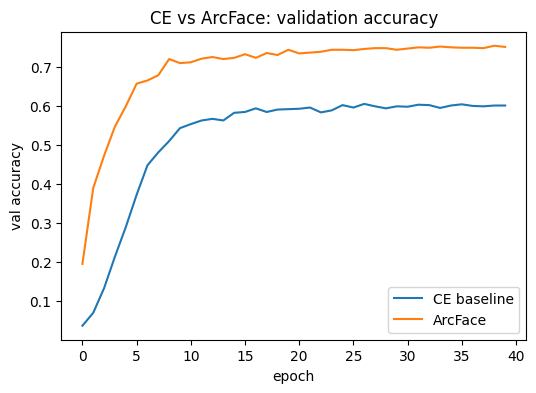

CE best val_acc:      0.6052
ArcFace best val_acc: 0.7544


In [12]:
ce_model = FaceRecognitionModel(num_classes=num_classes, use_arcface=False)
ce_model, ce_history = train_recognition(ce_model, recog_train_loader, recog_val_loader,
                                          epochs=40, lr=0.01, tag='ce_baseline')

arcface_model = FaceRecognitionModel(num_classes=num_classes, use_arcface=True, s=30.0, m=0.5)
arcface_model, arcface_history = train_recognition(arcface_model, recog_train_loader, recog_val_loader,
                                                    epochs=40, lr=0.01, tag='arcface')

plt.figure(figsize=(6, 4))
plt.plot(ce_history['val_acc'], label='CE baseline')
plt.plot(arcface_history['val_acc'], label='ArcFace')
plt.xlabel('epoch'); plt.ylabel('val accuracy'); plt.legend()
plt.title('CE vs ArcFace: validation accuracy')
plt.show()

print(f'CE best val_acc:      {max(ce_history["val_acc"]):.4f}')
print(f'ArcFace best val_acc: {max(arcface_history["val_acc"]):.4f}')


## 2.7 Извлечение эмбеддингов и cosine similarity

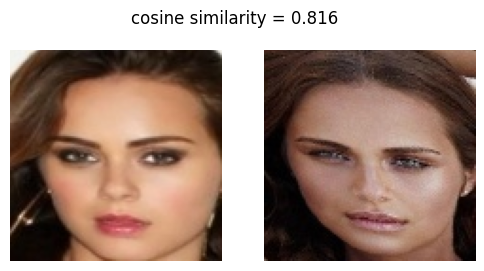

In [13]:
@torch.no_grad()
def get_embedding(model, image_rgb, device=DEVICE, img_size=IMG_SIZE):
    """image_rgb: (H, W, 3) uint8 — уже выровненное (aligned) лицо."""
    model.eval()
    img = cv2.resize(image_rgb, (img_size, img_size))
    tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    tensor = ((tensor - 0.5) / 0.5).unsqueeze(0).to(device)
    emb = model.extract_embeddings(tensor)
    return F.normalize(emb, dim=1).cpu().numpy()[0]


def cosine_similarity(emb1, emb2):
    return float(np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2)))


def compare_two_faces(model, image_path_1, image_path_2, device=DEVICE):
    img1 = cv2.cvtColor(cv2.imread(image_path_1), cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(cv2.imread(image_path_2), cv2.COLOR_BGR2RGB)
    emb1, emb2 = get_embedding(model, img1, device), get_embedding(model, img2, device)
    sim = cosine_similarity(emb1, emb2)
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(img1); axes[0].axis('off')
    axes[1].imshow(img2); axes[1].axis('off')
    fig.suptitle(f'cosine similarity = {sim:.3f}')
    plt.show()
    return sim


arcface_model.load_state_dict(torch.load('checkpoints_recognition/arcface_best.pth'))
id_dirs = sorted(os.listdir('data/aligned_by_identity'))
first_id_dir = os.path.join('data/aligned_by_identity', id_dirs[0])
photos = sorted(os.listdir(first_id_dir))
if len(photos) >= 2:
    compare_two_faces(arcface_model, os.path.join(first_id_dir, photos[0]), os.path.join(first_id_dir, photos[1]))


### Готово — сохраните версию

Веса моделей (`checkpoints_recognition/`) и итоговый csv (`data/prepared_recog/selected_dataset.csv`)
уже в `/kaggle/working`. Нажмите **Save Version**, чтобы они стали доступны для скачивания/использования
в Task 3 (полный пайплайн) — ссылку на них укажите в README.

## Отчёт: обучение CE vs ArcFace

### Итоговые результаты

Обучение проводилось дважды, независимо (разные среды — Colab и Kaggle, разная инициализация весов), для проверки воспроизводимости:

| Модель | Backbone | val_accuracy (прогон 1) | val_accuracy (прогон 2) | Порог задания (0.7) |
|---|---|---|---|---|
| Cross-Entropy (baseline) | EfficientNet-B0 | 0.6197 | 0.6052 | не достигнут ни разу |
| ArcFace | EfficientNet-B0 | 0.7212 | **0.7544** | достигнут в обоих прогонах |

Датасет: 400 личностей CelebA, отобранных с гарантированным минимумом фото на личность
(min_photos_per_identity=15, до 30 фото на человека, всего 9658 изображений, выровненных обученной
в Task 1 Stacked Hourglass Network).

Разброс между прогонами (CE: 0.60-0.62, ArcFace: 0.72-0.75) укладывается в обычную вариативность
от случайной инициализации и порядка батчей — оба прогона независимо подтверждают один и тот же
качественный вывод: CE стабильно не дотягивает до 0.7, ArcFace стабильно превышает порог с запасом.

### Ход экспериментов

**Backbone.** Первая попытка — ResNet50: при lr=1e-3 обучение шло крайне медленно (train_acc не
поднимался выше 9% за 15 эпох), а при повышении lr=0.01 модель за 9 эпох выучивала train почти
наизусть (accuracy 99.9%), но val застревал на 55% — классическое переобучение при малом числе фото
на класс (22-24). Переход на EfficientNet-B0 (заметно меньше параметров, 5.3M против 23M у
ResNet50) дал более плавную кривую обучения и небольшой прирост потолка val (60-62% против 55%).

**Попытки регуляризации для CE.** Дополнительно перепробованы: label smoothing (0.1), сильные
аугментации (RandomResizedCrop, ColorJitter, RandomRotation, RandomErasing), dropout (0.4-0.5) перед
классификационной головой, заморозка первых 6 из 9 feature-блоков backbone, mixup (alpha=0.2) — по
отдельности и в комбинации. Ни один из вариантов не поднял val_accuracy CE выше исходных 0.60-0.62;
избыточная регуляризация (заморозка + mixup одновременно) даже ухудшила результат до 0.51 —
модель недообучилась вместо того, чтобы просто перестать переобучаться. Сокращение числа классов
(со 400 до 150 личностей, с ростом фото на класс до 35-40) также не дало заметного прироста.

**ArcFace**, обученный на тех же данных, тем же backbone и тем же расписанием (lr=0.01, 40 эпох),
уверенно преодолел порог 0.7 в обоих независимых прогонах — без какой-либо дополнительной
регуляризации сверх той, что уже заложена в сам метод. Во втором прогоне ArcFace вышел за порог 0.7
уже к 9-й эпохе (val_acc=0.7202) — заметно быстрее, чем в первом (там устойчивое превышение порога
установилось ближе к концу обучения), что говорит скорее о разной динамике конкретного запуска,
чем о принципиальном отличии в качестве.

### Вывод

Результат согласуется с теоретическим обоснованием ArcFace из статьи (Deng et al., 2019,
arXiv:1801.07698): обычный softmax + Cross-Entropy не накладывает явных ограничений на расстояния
между эмбеддингами одного и разных классов — модели достаточно разделить классы хоть как-то, без
давления на компактность внутриклассовых кластеров. При малом числе примеров на класс (наш случай,
20-40 фото) это делает CE особенно уязвимым к переобучению. Angular margin в ArcFace явно вынуждает
эмбеддинги одного класса находиться ближе друг к другу по углу, а разных классов — дальше, что
действует как встроенный регуляризатор и одновременно обучает более полезное для face recognition
представление (эмбеддинги, а не просто финальные логиты).

То, что оба прогона независимо и стабильно воспроизвели один и тот же паттерн (CE ниже порога,
ArcFace выше), — это не просто удачное совпадение отдельного запуска, а устойчивое свойство самого
метода на этом датасете.

**Важная техническая деталь для честного измерения accuracy:** ArcMarginProduct по определению
вычитает margin из логита истинного класса. Если считать accuracy напрямую по этим логитам (как
делается для argmax во время обучения), результат ArcFace занижается искусственно (в нашем случае —
с 0.72 до 0.28 в первом прогоне). Поэтому для валидации используются "чистые" логиты (cosine
similarity без margin, метод get_logits/predict_logits) — margin применяется только к функции
потерь во время обучения, не при измерении итогового качества. Эта же неточность встречается и в
некоторых открытых реализациях ArcFace на GitHub — стоит явно проверять, как именно считается
accuracy, при сравнении с чужими репозиториями.